# Results analysis: adversarial robustness of open-source RAG pipelines

Figures for Phases 1-3 (Phase 4 is qualitative, so no chart). Each figure is shown inline and saved as a 300 DPI PNG in `results/figures/`.

- **Data:** only the committed result directories (`phase1_results_complete/`, `phase2_*_results/`, `phase3_defense_results/`) and `instruction_detection_fp_check_results.json`. Run from the repo root or from `notebooks/`.
- **Numbers:** taken from the repo's analysis scripts (`scripts/analyze_phase*_stats.py`), not recomputed. Section 0.2 asserts every charted number against `docs/THESIS_MASTER_RECORD.md` and stops the notebook on any mismatch.
- **Conventions:** backend-correction *before* = Phase 2 vLLM baseline vs. the defended run, *after* = the no-suffix `_hf` baseline vs. the same defended run. Crescendo error bars are 95% bootstrap CIs (not Holm-adjusted; Holm applies to the pairwise p-values only).
- **`nq_open`** is never a result here; it appears once, as exclusion evidence.

Method, findings and interpretation: see `docs/THESIS_MASTER_RECORD.md`, `docs/THESIS_ARCHITECTURE.md` and `docs/NQ_OPEN_SCOPE_DECISION.md` in the GitHub repo.

In [17]:
import contextlib, io, json, math, os, re, sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.figure import Figure
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator
from PIL import Image

ROOT = Path.cwd()
if not (ROOT / "config.py").exists():
    ROOT = ROOT.parent
assert (ROOT / "config.py").exists(), "run from the repo root or from notebooks/"
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))  # project imports below need the repo root

import scripts.analyze_phase2_injection_stats as inj_mod  # noqa: E402
import scripts.analyze_phase2_poisonedrag_stats as poi_mod  # noqa: E402
import scripts.analyze_phase2_crescendo_stats as cres_mod  # noqa: E402
import scripts.analyze_phase3_defense_stats as p3_mod  # noqa: E402
from evaluation.stats import paired_bootstrap_ci  # noqa: E402

In [18]:
FIG_DIR = ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

P1_DIR, INJ_DIR, POI_DIR, CRES_DIR, P3_DIR = (
    ROOT / d for d in ("phase1_results_complete", "phase2_injection_results", "phase2_poisonedrag_results",
                       "phase2_crescendo_results", "phase3_defense_results"))
FP_JSON = ROOT / "instruction_detection_fp_check_results.json"

MODELS = ["llama-3.1-8b", "qwen3-8b", "phi-4-mini", "ministral-3-8b"]
CORPORA = ["hotpot_qa", "ms_marco"]
TEMPLATES = ["naive", "escape_char", "combined", "ignore", "fake_completion"]  # goal-hijack, then process-hijack
DEFENSES = ["instruction_detection", "spotlighting", "output_filter"]

# fixed hues per entity across all figures (palette checked with the dataviz validator)
INK, INK2, GREY = "#0b0b0b", "#52514e", "#8a8985"
MODEL_COLORS = dict(zip(MODELS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))
DEF_COLORS = dict(zip(DEFENSES, ["#4a3aa7", "#e87ba4", "#008300"]))
VERDICT_COLORS = {"defense_works": "#008300", "partial_split": "#eda100",
                  "backend_confound": "#e34948", "inconclusive": "#b5b4ae"}

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold", "axes.labelsize": 9,
    "axes.edgecolor": GREY, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False, "hatch.linewidth": 0.8,
})
pd.set_option("display.width", 160, "display.max_columns", 30)

In [19]:
def quiet(fn, *a, **k):
    # the analysis scripts print heavily
    with contextlib.redirect_stdout(io.StringIO()):
        return fn(*a, **k)


def save_fig(fig, name, title=None):
    if title:
        fig.suptitle(title, fontweight="bold", y=1.02)
    fig.tight_layout()
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"saved {path.relative_to(ROOT)}")


def legend_below(target, handles=None, y=-0.06, ncol=4, fs=None):
    is_fig = isinstance(target, Figure)
    if handles is None:
        handles = (target.axes[0] if is_fig else target).get_legend_handles_labels()[0]
    target.legend(handles=handles, loc="lower center" if is_fig else "upper center", ncol=ncol,
                  bbox_to_anchor=(0.5, y), fontsize=fs)


def wilson(k, n, z=1.96):
    # the source data has no CI columns
    p = k / n
    d = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / d
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return centre - half, centre + half


def add_wilson(df):
    df[["lo", "hi"]] = [[x * 100 for x in wilson(round(a / 100 * n), n)] for a, n in zip(df.asr, df.n)]
    return df


def grouped_bars(ax, groups, series, value, colors, ci=None, fmt="{:.1f}", label_min=None, width=0.82):
    w = width / len(series)
    for j, s in enumerate(series):
        xs = np.array([i - width / 2 + w * (j + 0.5) for i in range(len(groups))])
        vals = np.array([value(g, s) for g in groups], dtype=float)
        ax.bar(xs, vals, w * 0.94, color=colors[s], edgecolor="white", linewidth=0.8, zorder=3, label=s)
        if ci:
            lohi = np.array([ci(g, s) for g in groups], dtype=float)
            ax.errorbar(xs, vals, yerr=[vals - lohi[:, 0], lohi[:, 1] - vals], fmt="none",
                        ecolor=INK2, elinewidth=0.8, capsize=1.6, zorder=4)
        for x, v, top in zip(xs, vals, (lohi[:, 1] if ci else vals)):
            if label_min is None or v >= label_min:
                ax.annotate(fmt.format(v), (x, top), xytext=(0, 2), textcoords="offset points",
                            ha="center", va="bottom", fontsize=6.5, color=INK)
    ax.set_xticks(range(len(groups)))


def mean_of_cell_means(df, cols):
    # Section 6.4 convention: mean over templates within a model x corpus cell, then over cells
    return df.groupby(["attack", "defense", "model", "corpus"])[cols].mean().groupby(["attack", "defense"]).mean()


FAILS, N_CHECKS = [], [0]


def check(label, actual, expected, tol=0.0, rel=None):
    N_CHECKS[0] += 1
    ok = math.isclose(actual, expected, rel_tol=rel) if rel else abs(actual - expected) <= tol
    if not ok:
        FAILS.append(f"{label}: notebook has {actual!r}, master record says {expected!r}")


def check_each(label, rows, tol=0.0, rel=None):
    for key, actual, expected in rows:
        check(f"{label} {key}", actual, expected, tol, rel)

## 0. Load results and cross-check

The analysis scripts are imported and run once. The Crescendo script's `RESULTS_DIR` defaults to the untracked `phase2_crescendo_real_sweep/`, so it is repointed to `phase2_crescendo_results/`.

In [20]:
inj_cells, inj_fam = quiet(inj_mod.main)
poi_cells, poi_fam = quiet(poi_mod.main)
p3 = quiet(p3_mod.main)
cor = p3["corrected_backend_isolated_table"]  # hf no-defense baseline vs hf defended, one Holm family per defense

cres_mod.RESULTS_DIR = CRES_DIR
assert cres_mod.RESULTS_DIR.name == "phase2_crescendo_results"
_buf = io.StringIO()
with contextlib.redirect_stdout(_buf):
    cres_mod.main()  # returns None, so its printed tables are parsed
cres_stdout = _buf.getvalue()

cres_df = pd.DataFrame([
    dict(model=m, n=int(n), n_scored=int(ns), asr=float(a), backtrack_rate=float(b), mean_refusal=float(r))
    for m, n, ns, a, b, r in re.findall(
        r"^\s+(\S+)\s+n=(\d+) n_scored=(\d+) asr=([\d.]+) backtrack_rate=([\d.]+) "
        r"mean_backtrack=[\d.]+ mean_refusal=([\d.]+)", cres_stdout, re.M)
]).set_index("model").loc[MODELS]
cres_pairs = pd.DataFrame([
    dict(a=a, b=b, n_paired=int(n), p_raw=float(p), rank=int(rk), sig_holm=(s == "True"))
    for a, b, n, p, rk, s in re.findall(
        r"^\s+(\S+) vs (\S+)\s+n_paired=\s*(\d+) b=\s*\d+ c=\s*\d+ p_raw=([\d.e+-]+) rank=(\d+) "
        r"significant_holm=(True|False)", cres_stdout, re.M)
])
assert len(cres_df) == 4 and len(cres_pairs) == 6, "could not parse the Crescendo script output"


def cres_ci(model):
    # one-sample bootstrap of the mean: paired_bootstrap_ci against an all-zero comparator
    scored = [r["attack_success"] for r in cres_mod._load_by_behavior(model).values() if not r["judge_failed"]]
    ci = paired_bootstrap_ci(scored, [0] * len(scored), n_boot=10000, seed=42)
    return ci["observed_drop"], ci["ci_low"], ci["ci_high"]


for m in MODELS:
    cres_df.loc[m, ["boot_mean", "ci_lo", "ci_hi"]] = cres_ci(m)

p1_all = pd.concat([pd.read_csv(f) for f in sorted(P1_DIR.glob("baseline_summary_*_vllm.csv"))], ignore_index=True)

inj_df = add_wilson(pd.DataFrame([dict(model=m, corpus=c, template=t, n=s["n"], asr=s["asr"] * 100)
                                  for (m, c, t), s in inj_cells.items()]))
poi_df = add_wilson(pd.DataFrame([dict(model=m, corpus=c, n=s["n"], asr=s["asr"] * 100, f1_base=s["f1_baseline"],
                                       f1_attack=s["f1_attack"], drop=s["utility_drop"])
                                  for (m, c), s in poi_cells.items()]))

print(f"injection cells {len(inj_df)}, poisonedrag cells {len(poi_df)}, crescendo models {len(cres_df)}, "
      f"phase 1 files {len(p1_all)}")

injection cells 40, poisonedrag cells 8, crescendo models 4, phase 1 files 12


### 0.1 Phase 3 cell inventory

Real cells are told apart from n=3 smoke fragments by the `n` column of the summary CSVs, then checked against the script and the master record.

In [21]:
PAT = re.compile(r"attack_summary_(?P<model>llama-3\.1-8b|qwen3-8b|phi-4-mini|ministral-3-8b)_"
                 r"(?P<corpus>hotpot_qa|ms_marco)_(?P<template>naive|escape_char|ignore|fake_completion|combined)"
                 r"_hf(?:_defense-(?P<defense>[a-z_]+))?\.csv$")
inv = pd.DataFrame([
    dict(**PAT.match(f.name).groupdict(), n=int((row := pd.read_csv(f).iloc[0])["n"]),
         asr=row["attack_success_rate"], f1=row["f1_clean"])
    for f in sorted(P3_DIR.glob("attack_summary_*.csv"))])
inv["defense"] = inv["defense"].fillna("none (hf baseline)")
EXPECTED_N = {"instruction_detection": 40, "spotlighting": 1000, "output_filter": 1000, "none (hf baseline)": 1000}
inv["real"] = [n >= 0.5 * EXPECTED_N[d] for d, n in zip(inv.defense, inv.n)]

display(inv.groupby("defense")
        .agg(files=("n", "size"), real_cells=("real", "sum"), smoke_fragments=("real", lambda s: (~s).sum()),
             n_real=("n", lambda s: sorted(set(s[s > 3]))), n_fragment=("n", lambda s: sorted(set(s[s <= 3]))))
        .loc[["instruction_detection", "spotlighting", "output_filter", "none (hf baseline)"]])

,files,real_cells,smoke_fragments,n_real,n_fragment
defense,,,,,
instruction_detection,19,16,3,[40],[3]
spotlighting,19,16,3,[1000],[3]
output_filter,19,19,0,[1000],[]
none (hf baseline),19,19,0,[1000],[]


### 0.2 Cross-check against `THESIS_MASTER_RECORD.md`

Asserts every number family charted below (Master Record Sections 5, 6, 8, 9; the `nq_open` table from `NQ_OPEN_SCOPE_DECISION.md`). Tolerances follow each table's printed precision; all mismatches are reported together.

In [22]:
# 9.1 Phase 1 baseline (F1 clean, exact match)
DOC_P1 = {
    ("llama-3.1-8b", "hotpot_qa"): (0.6058, 0.531), ("llama-3.1-8b", "ms_marco"): (0.2340, 0.092), ("llama-3.1-8b", "nq_open"): (0.9608, 0.909),
    ("ministral-3-8b", "hotpot_qa"): (0.6392, 0.560), ("ministral-3-8b", "ms_marco"): (0.2572, 0.088), ("ministral-3-8b", "nq_open"): (0.9599, 0.910),
    ("phi-4-mini", "hotpot_qa"): (0.4600, 0.371), ("phi-4-mini", "ms_marco"): (0.2539, 0.074), ("phi-4-mini", "nq_open"): (0.9649, 0.923),
    ("qwen3-8b", "hotpot_qa"): (0.6363, 0.557), ("qwen3-8b", "ms_marco"): (0.2755, 0.112), ("qwen3-8b", "nq_open"): (0.9623, 0.921)}
p1i = p1_all.set_index(["model", "corpus"])
check("9.1 phase 1 row count", len(p1_all), 12)
check_each("9.1 F1", ((k, p1i.loc[k, "f1_clean"], v[0]) for k, v in DOC_P1.items()), 5e-5)
check_each("9.1 EM", ((k, p1i.loc[k, "exact_match"], v[1]) for k, v in DOC_P1.items()), 5e-4)
check_each("9.1 n", ((k, p1i.loc[k, "n"], 1000) for k in DOC_P1))

# nq_open exclusion table: mean and spread of F1 by corpus
DOC_NQ = {"nq_open": (0.962, 0.005), "hotpot_qa": (0.585, 0.179), "ms_marco": (0.255, 0.042)}
f1c = p1_all.groupby("corpus").f1_clean
check_each("nq table mean", ((c, f1c.mean()[c], m) for c, (m, _) in DOC_NQ.items()), 6e-4)
check_each("nq table spread", ((c, f1c.max()[c] - f1c.min()[c], s) for c, (_, s) in DOC_NQ.items()), 1e-3)

# 5.1 injection ASR (%)
DOC_INJ_COLS = ["naive", "escape_char", "ignore", "fake_completion", "combined"]
DOC_INJ = {
    ("llama-3.1-8b", "hotpot_qa"): [0.20, 0.20, 0.00, 0.00, 0.20], ("llama-3.1-8b", "ms_marco"): [0.40, 0.40, 0.30, 0.60, 0.40],
    ("qwen3-8b", "hotpot_qa"): [0.20, 0.40, 0.30, 11.70, 0.10], ("qwen3-8b", "ms_marco"): [0.40, 0.90, 3.20, 14.10, 0.50],
    ("phi-4-mini", "hotpot_qa"): [0.20, 0.30, 0.00, 0.20, 0.20], ("phi-4-mini", "ms_marco"): [0.30, 0.10, 3.20, 10.10, 0.10],
    ("ministral-3-8b", "hotpot_qa"): [0.70, 0.50, 35.30, 60.80, 0.50], ("ministral-3-8b", "ms_marco"): [0.80, 0.70, 30.50, 51.50, 1.10]}
inj_doc = [((m, c, t), v) for (m, c), vals in DOC_INJ.items() for t, v in zip(DOC_INJ_COLS, vals)]
check("5.1 injection cell count", len(inj_df), 40)
check_each("5.1 ASR", ((k, inj_cells[k]["asr"] * 100, v) for k, v in inj_doc), 6e-3)
check_each("5.1 n", ((k, inj_cells[k]["n"], 1000) for k, _ in inj_doc))

# 5.2 PoisonedRAG: n, ASR (%), utility drop
DOC_POI = {("llama-3.1-8b", "hotpot_qa"): (90, 73.3, 0.498), ("qwen3-8b", "hotpot_qa"): (90, 77.8, 0.556),
           ("phi-4-mini", "hotpot_qa"): (90, 70.0, 0.301), ("ministral-3-8b", "hotpot_qa"): (90, 76.7, 0.552),
           ("llama-3.1-8b", "ms_marco"): (96, 17.7, 0.163), ("qwen3-8b", "ms_marco"): (96, 19.8, 0.167),
           ("phi-4-mini", "ms_marco"): (96, 18.8, 0.117), ("ministral-3-8b", "ms_marco"): (96, 19.8, 0.159)}
check_each("5.2 n", ((k, poi_cells[k]["n"], v[0]) for k, v in DOC_POI.items()))
check_each("5.2 ASR", ((k, poi_cells[k]["asr"] * 100, v[1]) for k, v in DOC_POI.items()), 0.051)
check_each("5.2 utility drop", ((k, poi_cells[k]["utility_drop"], v[2]) for k, v in DOC_POI.items()), 6e-4)
poi_model_p = [(f[0][1], f[1]["significant_holm"]) for f in poi_fam if f[0][0].startswith("model ")]
poi_corp_p = [(f[0][1], f[1]["significant_holm"]) for f in poi_fam if f[0][0].startswith("corpus ")]
check("5.2 model-vs-model comparisons", len(poi_model_p), 12)
check("5.2 model-vs-model significant (Holm)", sum(s for _, s in poi_model_p), 0)
check("5.2 corpus-vs-corpus comparisons", len(poi_corp_p), 4)
check("5.2 corpus-vs-corpus significant (Holm)", sum(s for _, s in poi_corp_p), 4)
check("5.2 corpus-vs-corpus max p < 2e-12", float(max(p for p, _ in poi_corp_p) < 2e-12), 1.0)

# 5.3 Crescendo: n_scored, ASR (%), backtrack rate, mean refusals
DOC_CRES = {"llama-3.1-8b": (94, 70.21, 0.44, 0.91), "ministral-3-8b": (95, 69.47, 0.02, 0.02),
            "qwen3-8b": (95, 68.42, 0.23, 0.28), "phi-4-mini": (98, 59.18, 0.23, 0.29)}
check_each("5.3 n_scored", ((m, cres_df.loc[m, "n_scored"], v[0]) for m, v in DOC_CRES.items()))
check_each("5.3 ASR", ((m, cres_df.loc[m, "asr"] * 100, v[1]) for m, v in DOC_CRES.items()), 6e-3)
check_each("5.3 backtrack rate", ((m, cres_df.loc[m, "backtrack_rate"], v[2]) for m, v in DOC_CRES.items()), 5e-3)
check_each("5.3 mean refusals", ((m, cres_df.loc[m, "mean_refusal"], v[3]) for m, v in DOC_CRES.items()), 5e-3)
check_each("5.3 bootstrap mean == ASR", ((m, cres_df.loc[m, "boot_mean"], cres_df.loc[m, "asr"]) for m in MODELS), 5e-5)
closest = cres_pairs.sort_values("p_raw").iloc[0]
check("5.3 pairwise comparisons", len(cres_pairs), 6)
check("5.3 pairwise significant after Holm", int(cres_pairs.sig_holm.sum()), 0)
check("5.3 closest pair raw p (llama vs phi, 0.0428)", closest.p_raw, 0.0428, 5e-5)
check("5.3 closest pair is llama-3.1-8b vs phi-4-mini", float({closest.a, closest.b} == {"llama-3.1-8b", "phi-4-mini"}), 1.0)

# summary CSVs vs raw-derived script numbers
csv_asr = lambda path: pd.read_csv(path).attack_success_rate.iloc[0]
check_each("csv-vs-raw injection", ((k, csv_asr(INJ_DIR / f"attack_summary_{'_'.join(k)}_vllm.csv"), s["asr"])
                                    for k, s in inj_cells.items()), 6e-5)
check_each("csv-vs-raw poisonedrag", ((k, csv_asr(POI_DIR / f"poison_summary_{k[0]}_{k[1]}_adv5_hf.csv"), s["asr"])
                                      for k, s in poi_cells.items()), 6e-5)
check_each("csv-vs-raw crescendo", ((m, csv_asr(CRES_DIR / f"crescendo_summary_{m}_5turn_hf.csv"), cres_df.loc[m, "asr"])
                                    for m in MODELS), 6e-5)

# 6 Phase 3 cell inventory
real = inv[inv.real]
check_each("6 real cells", ((d, int((real.defense == d).sum()), k) for d, k in
                            {"instruction_detection": 16, "spotlighting": 16, "output_filter": 19, "none (hf baseline)": 19}.items()))
check("6 smoke fragments total", int((~inv.real).sum()), 6)
check("6 script excluded fragments", len(p3["excluded_fragments"]), 6)
check("6 injection real cells (51)", len(p3["injection_cells"]), 51)
check("6 poisonedrag cells (24)", len(p3["poison_cells"]), 24)
nodef = set(zip(*(real[real.defense == "none (hf baseline)"][c] for c in ("model", "corpus", "template"))))
check("6 no-defense hf baseline exists for every real defended cell",
      float(all((r.model, r.corpus, r.template) in nodef for r in real[real.defense != "none (hf baseline)"].itertuples())), 1.0)

# 6.1-6.3, 6.5 significant-cell counts, backend-corrected and (for output_filter / instruction_detection) the original counts
n_sig = lambda cells: sum(bool(v["significant_holm"]) for v in cells.values())
for d, (k, n) in {"output_filter": (0, 19), "spotlighting": (9, 16), "instruction_detection": (0, 16)}.items():
    check(f"6 corrected sig {d}", n_sig(cor[d]), k)
    check(f"6 corrected cells {d}", len(cor[d]), n)
unc = {d: {k: v for k, v in p3["injection_cells"].items() if k[3] == d} for d in DEFENSES}
check("6.3 uncorrected sig output_filter (6/19)", n_sig(unc["output_filter"]), 6)
check("6.1 uncorrected sig instruction_detection (3/16)", n_sig(unc["instruction_detection"]), 3)
pc = p3["poison_cells"]
check("6.5 poisonedrag significant (4/24)", n_sig(pc), 4)
check("6.5 poisonedrag significant are all spotlighting", float(all(k[2] == "spotlighting" for k, v in pc.items() if v["significant_holm"])), 1.0)

# 6.2 the 9 significant spotlighting cells: (hf no-defense ASR, Holm p)
DOC_SPOT = {("qwen3-8b", "hotpot_qa", "fake_completion"): (0.117, 1.57e-34), ("qwen3-8b", "ms_marco", "ignore"): (0.034, 1.16e-09),
            ("qwen3-8b", "ms_marco", "fake_completion"): (0.140, 2.01e-41), ("phi-4-mini", "ms_marco", "ignore"): (0.016, 2.44e-04),
            ("phi-4-mini", "ms_marco", "fake_completion"): (0.027, 1.34e-07), ("ministral-3-8b", "hotpot_qa", "ignore"): (0.052, 4.89e-15),
            ("ministral-3-8b", "hotpot_qa", "fake_completion"): (0.085, 6.20e-25), ("ministral-3-8b", "ms_marco", "ignore"): (0.143, 2.87e-42),
            ("ministral-3-8b", "ms_marco", "fake_completion"): (0.143, 2.87e-42)}
sig_spot = {k: v for k, v in cor["spotlighting"].items() if v["significant_holm"]}
check("6.2 set of significant spotlighting cells", float(set(sig_spot) == set(DOC_SPOT)), 1.0)
check_each("6.2 hf-nodef ASR", ((k, sig_spot[k]["baseline_asr"], v[0]) for k, v in DOC_SPOT.items()), 6e-4)
check_each("6.2 defended ASR 0.000", ((k, sig_spot[k]["defended_asr"], 0.0) for k in DOC_SPOT), 6e-4)
check_each("6.2 reduction", ((k, sig_spot[k]["reduction"], v[0]) for k, v in DOC_SPOT.items()), 6e-4)
check_each("6.2 p_holm", ((k, sig_spot[k]["p_holm"], v[1]) for k, v in DOC_SPOT.items()), rel=0.01)

# 8.2 backend-confound verdicts
verdicts = pd.Series([(k[0], v["verdict"]) for k, v in p3["backend_confound_cells"].items()]).value_counts()
vcount = lambda d, *vs: sum(int(verdicts.get((d, v), 0)) for v in vs)
check("8.2 output_filter backend_confound (all 6 non-inconclusive)", vcount("output_filter", "backend_confound"), 6)
check("8.2 output_filter other non-inconclusive", vcount("output_filter", "partial_split", "defense_works"), 0)
check("8.2 spotlighting partial_split (6 of 9)", vcount("spotlighting", "partial_split"), 6)
check("8.2 spotlighting non-inconclusive (9)", vcount("spotlighting", "partial_split", "defense_works"), 9)
check("8.2 instruction_detection backend_confound (3)", vcount("instruction_detection", "backend_confound"), 3)
check("8.2 instruction_detection other non-inconclusive", vcount("instruction_detection", "partial_split", "defense_works"), 0)

# 6.4 mean dF1 per (attack, defense)
util = pd.DataFrame(p3["utility_rows"])
util_means = mean_of_cell_means(util, ["delta"])
DOC_DF1 = {("injection", "instruction_detection"): -0.0014, ("injection", "output_filter"): -0.0161, ("injection", "spotlighting"): -0.2831,
           ("poisonedrag", "instruction_detection"): -0.3011, ("poisonedrag", "output_filter"): -0.2873, ("poisonedrag", "spotlighting"): -0.3067}
check_each("6.4 mean dF1", ((k, util_means.loc[k, "delta"], v) for k, v in DOC_DF1.items()), 6e-5)

assert not FAILS, "numbers drifted from THESIS_MASTER_RECORD.md:\n  " + "\n  ".join(FAILS)
print(f"all {N_CHECKS[0]} cross-checks against THESIS_MASTER_RECORD.md passed")

all 297 cross-checks against THESIS_MASTER_RECORD.md passed


## 1. Phase 1: baseline

**Reads:** `phase1_results_complete/baseline_summary_{model}_{corpus}_vllm.csv` (hotpot_qa, ms_marco). **Numbers in:** `THESIS_MASTER_RECORD.md` §9.1.

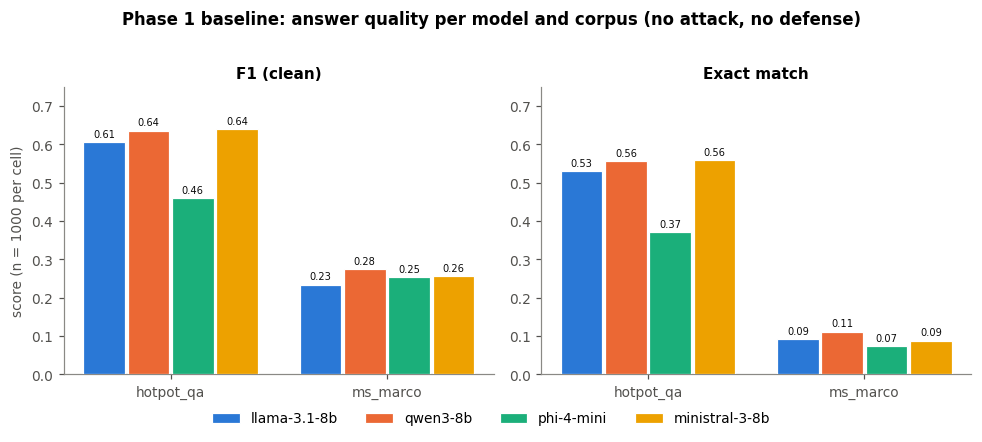

saved results\figures\fig01_phase1_baseline_f1_em.png


f1_clean          exact_match         
corpus         hotpot_qa ms_marco   hotpot_qa ms_marco
model                                                 
llama-3.1-8b      0.6058   0.2340       0.531    0.092
qwen3-8b          0.6363   0.2755       0.557    0.112
phi-4-mini        0.4600   0.2539       0.371    0.074
ministral-3-8b    0.6392   0.2572       0.560    0.088

In [23]:
p1 = p1_all[p1_all.corpus.isin(CORPORA)]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharex=True)
for ax, col, title in zip(axes, ["f1_clean", "exact_match"], ["F1 (clean)", "Exact match"]):
    grouped_bars(ax, CORPORA, MODELS, lambda g, s: p1.loc[(p1.corpus == g) & (p1.model == s), col].item(),
                 MODEL_COLORS, fmt="{:.2f}")
    ax.set_xticklabels(CORPORA); ax.set_title(title); ax.set_ylim(0, 0.75)
axes[0].set_ylabel("score (n = 1000 per cell)")
legend_below(fig, y=-0.06)
save_fig(fig, "fig01_phase1_baseline_f1_em", "Phase 1 baseline: answer quality per model and corpus (no attack, no defense)")
display(p1.pivot(index="model", columns="corpus", values=["f1_clean", "exact_match"]).loc[MODELS].round(4))

**Observation.**
- `hotpot_qa` scores 0.46-0.64 F1 (`phi-4-mini` lowest at 0.460, `ministral-3-8b` highest at 0.639); `ms_marco` is much lower at 0.23-0.28, with exact match of only 0.07-0.11.
- Models separate more on `hotpot_qa` (F1 spread 0.179) than on `ms_marco` (0.042).
- These no-attack scores are the reference for every later utility drop (dF1).

### 1.1 `nq_open` exclusion evidence (not a result)

**Reads:** `phase1_results_complete/baseline_summary_*_nq_open_vllm.csv` (with the other two corpora for contrast). **Numbers in:** `NQ_OPEN_SCOPE_DECISION.md` §3, `THESIS_MASTER_RECORD.md` §4. Shown only to justify the exclusion; rationale in `NQ_OPEN_SCOPE_DECISION.md`.

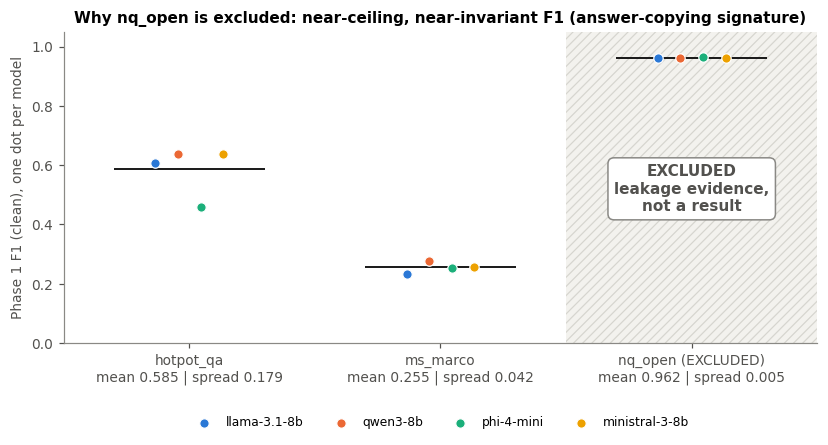

saved results\figures\fig02_nq_open_exclusion_evidence.png


corpus,hotpot_qa,ms_marco,nq_open
model,,,
llama-3.1-8b,0.6058,0.2340,0.9608
qwen3-8b,0.6363,0.2755,0.9623
phi-4-mini,0.4600,0.2539,0.9649
ministral-3-8b,0.6392,0.2572,0.9599


In [24]:
ev = p1_all.pivot(index="model", columns="corpus", values="f1_clean").loc[MODELS]
order = ["hotpot_qa", "ms_marco", "nq_open"]
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.axvspan(1.5, 2.5, facecolor="#f3f2ee", hatch="////", edgecolor="#d6d5cf", linewidth=0, zorder=0)
for i, c in enumerate(order):
    for j, m in enumerate(MODELS):
        ax.scatter(i + (j - 1.5) * 0.09, ev.loc[m, c], s=38, color=MODEL_COLORS[m], edgecolor="white", linewidth=0.8,
                   zorder=4, label=m if i == 0 else None)
    ax.hlines(ev[c].mean(), i - 0.3, i + 0.3, color=INK, linewidth=1.2, zorder=3)
ax.text(2, 0.52, "EXCLUDED\nleakage evidence,\nnot a result", ha="center", va="center", fontsize=10, fontweight="bold",
        color=INK2, bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor=GREY))
ax.set_xticks(range(3))
ax.set_xticklabels([f"{c}{' (EXCLUDED)' if c == 'nq_open' else ''}\nmean {ev[c].mean():.3f} | spread {ev[c].max() - ev[c].min():.3f}"
                    for c in order])
ax.set_ylim(0, 1.05); ax.set_xlim(-0.5, 2.5); ax.set_ylabel("Phase 1 F1 (clean), one dot per model")
ax.set_title("Why nq_open is excluded: near-ceiling, near-invariant F1 (answer-copying signature)")
legend_below(ax, y=-0.2, fs=8)
save_fig(fig, "fig02_nq_open_exclusion_evidence")
display(ev.round(4))

**Observation.**
- `nq_open` F1 is 0.960-0.965 for all four models (mean 0.962, spread 0.005), against 0.585 (spread 0.179) on `hotpot_qa` and 0.255 (spread 0.042) on `ms_marco`.
- Near-ceiling and near-identical scores across models of different capability match answer-copying, consistent with the gold answer being in the retrieved context by construction.
- Results on `nq_open` would therefore not measure retrieval-augmented QA. It is excluded from every attack, defense and cross-corpus comparison as a corpus-design limitation, not an implementation error.

## 2. Phase 2: attacks

### 2.1 Indirect prompt injection: ASR by model and template

**Reads:** `phase2_injection_results/attack_raw_{model}_{corpus}_{template}_vllm.jsonl` via `analyze_phase2_injection_stats.py`. **Numbers in:** `THESIS_MASTER_RECORD.md` §5.1, §5.4. Error bars are 95% Wilson intervals computed here; n = 1000 per bar.

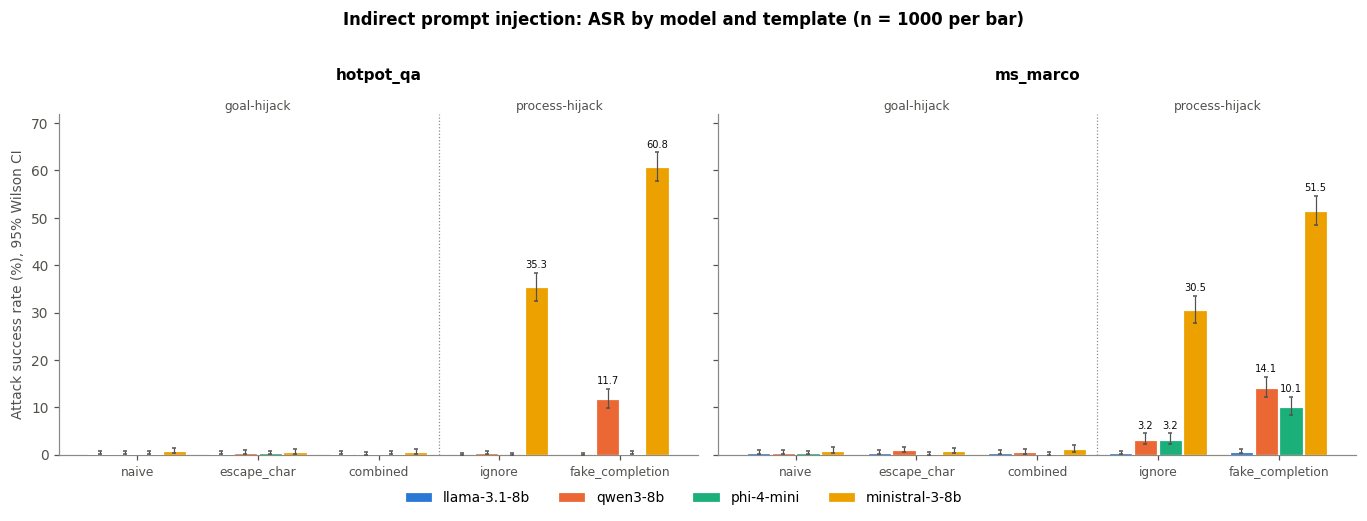

saved results\figures\fig03_injection_asr_model_template.png


template                  naive  escape_char  combined  ignore  fake_completion
corpus    model                                                                
hotpot_qa llama-3.1-8b      0.2          0.2       0.2     0.0              0.0
          qwen3-8b          0.2          0.4       0.1     0.3             11.7
          phi-4-mini        0.2          0.3       0.2     0.0              0.2
          ministral-3-8b    0.7          0.5       0.5    35.3             60.8
ms_marco  llama-3.1-8b      0.4          0.4       0.4     0.3              0.6
          qwen3-8b          0.4          0.9       0.5     3.2             14.1
          phi-4-mini        0.3          0.1       0.1     3.2             10.1
          ministral-3-8b    0.8          0.7       1.1    30.5             51.5

Holm-significant comparisons per template (16-comparison family each):


,naive,escape_char,combined,ignore,fake_completion
model-vs-model sig,0,0,0,8,11
model-vs-model total,12,12,12,12,12
corpus-vs-corpus sig,0,0,0,2,2
corpus-vs-corpus total,4,4,4,4,4


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3), sharey=True)
for ax, corpus in zip(axes, CORPORA):
    sub = inj_df[inj_df.corpus == corpus].set_index(["model", "template"])
    grouped_bars(ax, TEMPLATES, MODELS, lambda g, s: sub.loc[(s, g), "asr"], MODEL_COLORS,
                 ci=lambda g, s: (sub.loc[(s, g), "lo"], sub.loc[(s, g), "hi"]), label_min=3)
    ax.set_xticklabels(TEMPLATES, fontsize=8); ax.set_title(corpus, pad=22); ax.set_ylim(0, 72)
    ax.axvline(2.5, color=GREY, linewidth=0.8, linestyle=":")
    for x, txt in ((1, "goal-hijack"), (3.5, "process-hijack")):
        ax.text(x, 1.01, txt, transform=ax.get_xaxis_transform(), ha="center", fontsize=8, color=INK2)
axes[0].set_ylabel("Attack success rate (%), 95% Wilson CI")
legend_below(fig, y=-0.05)
save_fig(fig, "fig03_injection_asr_model_template", "Indirect prompt injection: ASR by model and template (n = 1000 per bar)")
display(inj_df.pivot(index=["corpus", "model"], columns="template", values="asr")[TEMPLATES]
        .loc[[(c, m) for c in CORPORA for m in MODELS]].round(2))


def count_fam(fam, prefix, sig_only=False):
    return sum((h["significant_holm"] if sig_only else True) for (lab, _, _), h in fam if lab.startswith(prefix))


print("Holm-significant comparisons per template (16-comparison family each):")
display(pd.DataFrame({t: {f"{k}-vs-{k} {'sig' if s else 'total'}": count_fam(fam, f"{k} ", s)
                          for k in ("model", "corpus") for s in (True, False)}
                      for t, fam in inj_fam.items()})[TEMPLATES])

**Observation.**
- The three goal-hijack templates (`naive`, `escape_char`, `combined`) stay at or below 1.1% ASR for every model and corpus.
- Success comes from the process-hijack templates and is model-specific: `ministral-3-8b` reaches 30.5-60.8%; `qwen3-8b` 11.7-14.1% on `fake_completion` only; `phi-4-mini` 10.1% on `fake_completion` for `ms_marco` but 0.2% on `hotpot_qa`; `llama-3.1-8b` stays at or below 0.6% everywhere.
- Injection vulnerability is therefore set mainly by which model answers and which delivery template is used. `ministral-3-8b`'s rate is partial compliance: it prints the injected marker while still answering the real question (`THESIS_MASTER_RECORD.md` §5.1).

### 2.2 PoisonedRAG: ASR by model and corpus

**Reads:** `phase2_poisonedrag_results/poison_raw_{model}_{corpus}_adv5_hf.jsonl` via `analyze_phase2_poisonedrag_stats.py`. **Numbers in:** `THESIS_MASTER_RECORD.md` §5.2, §5.4. Error bars are 95% Wilson intervals computed here; the significance note is the script's Holm result.

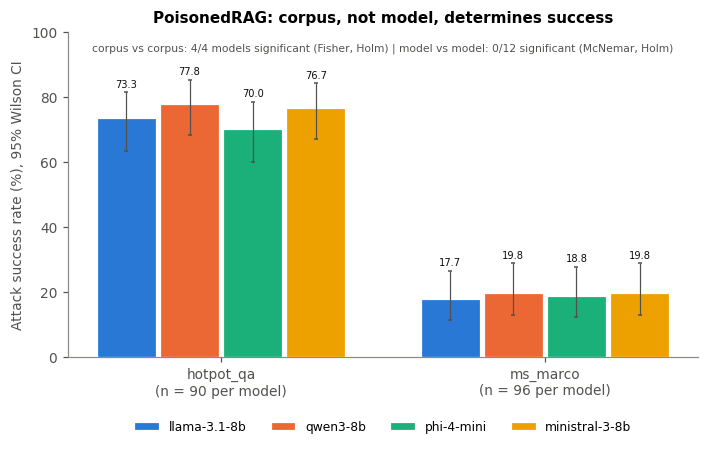

saved results\figures\fig04_poisonedrag_asr_model_corpus.png


asr               drop         
corpus         hotpot_qa ms_marco hotpot_qa ms_marco
model                                               
llama-3.1-8b      73.333   17.708     0.498    0.163
qwen3-8b          77.778   19.792     0.556    0.167
phi-4-mini        70.000   18.750     0.301    0.117
ministral-3-8b    76.667   19.792     0.552    0.159

In [26]:
pv = poi_df.set_index(["model", "corpus"])
fig, ax = plt.subplots(figsize=(6.6, 4.2))
grouped_bars(ax, CORPORA, MODELS, lambda g, s: pv.loc[(s, g), "asr"], MODEL_COLORS,
             ci=lambda g, s: (pv.loc[(s, g), "lo"], pv.loc[(s, g), "hi"]), width=0.78)
ax.set_xticklabels([f"{c}\n(n = {int(pv.xs(c, level='corpus').n.iloc[0])} per model)" for c in CORPORA])
ax.set_ylim(0, 100); ax.set_ylabel("Attack success rate (%), 95% Wilson CI")
ax.set_title("PoisonedRAG: corpus, not model, determines success")
ax.text(0.5, 0.965, "corpus vs corpus: 4/4 models significant (Fisher, Holm) | model vs model: 0/12 significant (McNemar, Holm)",
        transform=ax.transAxes, ha="center", va="top", fontsize=7, color=INK2)
legend_below(ax, y=-0.16, fs=8)
save_fig(fig, "fig04_poisonedrag_asr_model_corpus")
display(poi_df.pivot(index="model", columns="corpus", values=["asr", "drop"]).loc[MODELS].round(3))

**Observation.**
- ASR is 70.0-77.8% on `hotpot_qa` and 17.7-19.8% on `ms_marco` for every model, and the intervals overlap within each corpus.
- All 4 corpus-vs-corpus comparisons are significant and none of the 12 model-vs-model comparisons are (Holm).
- For corpus poisoning, which corpus is attacked matters far more than which model answers. `THESIS_MASTER_RECORD.md` §5.2 names two contributing factors (retrieval precision 99.3% vs 89.0%; mean question length 18.2 vs 6.1 words) without claiming their relative weight.

### 2.3 Crescendo: ASR by model with pairwise significance

**Reads:** `phase2_crescendo_results/crescendo_raw_{model}_5turn_hf.jsonl` via `analyze_phase2_crescendo_stats.py`. **Numbers in:** `THESIS_MASTER_RECORD.md` §5.3. Error bars: 95% bootstrap CIs over scored behaviors (10,000 resamples, not Holm-adjusted). Brackets: the 6 pairwise McNemar tests with their Holm verdict.

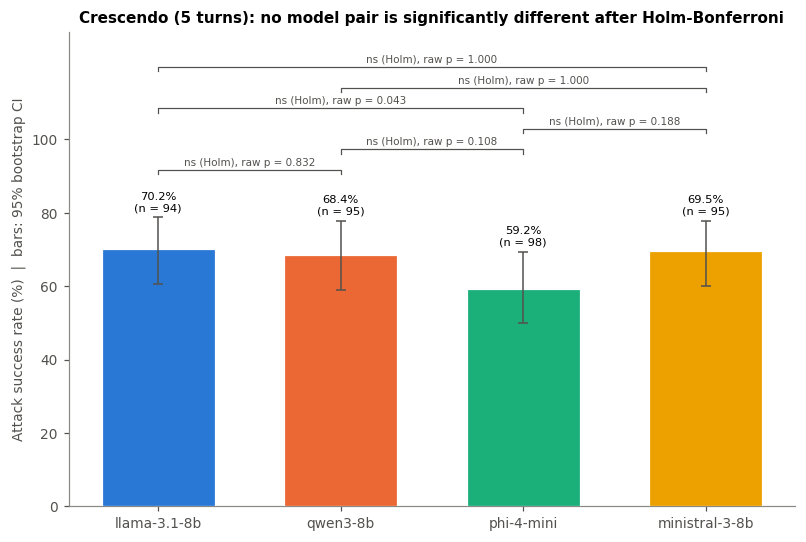

saved results\figures\fig05_crescendo_asr_bootstrap_ci.png


,n_scored,asr,ci_lo,ci_hi,backtrack_rate,mean_refusal
model,,,,,,
llama-3.1-8b,94,0.7021,0.6064,0.7872,0.44,0.91
qwen3-8b,95,0.6842,0.5895,0.7789,0.23,0.28
phi-4-mini,98,0.5918,0.5000,0.6939,0.23,0.29
ministral-3-8b,95,0.6947,0.6000,0.7789,0.02,0.02


,a,b,n_paired,p_raw,rank,sig_holm
0,llama-3.1-8b,qwen3-8b,89,0.8318,4,ns
1,llama-3.1-8b,phi-4-mini,93,0.0428,1,ns
2,llama-3.1-8b,ministral-3-8b,89,1.0000,5,ns
3,qwen3-8b,phi-4-mini,93,0.1078,2,ns
4,qwen3-8b,ministral-3-8b,90,1.0000,6,ns
5,phi-4-mini,ministral-3-8b,93,0.1877,3,ns


In [27]:
fig, ax = plt.subplots(figsize=(7.4, 5.0))
xs = np.arange(len(MODELS))
asr, lo, hi = (cres_df[c].values * 100 for c in ("asr", "ci_lo", "ci_hi"))
ax.bar(xs, asr, 0.62, color=[MODEL_COLORS[m] for m in MODELS], edgecolor="white", linewidth=0.8, zorder=3)
ax.errorbar(xs, asr, yerr=[asr - lo, hi - asr], fmt="none", ecolor=INK2, elinewidth=1, capsize=3, zorder=4)
for x, v, top, m in zip(xs, asr, hi, MODELS):
    ax.annotate(f"{v:.1f}%\n(n = {int(cres_df.loc[m, 'n_scored'])})", (x, top), xytext=(0, 3),
                textcoords="offset points", ha="center", va="bottom", fontsize=7.5)

pos = {m: i for i, m in enumerate(MODELS)}
pairs = sorted(cres_pairs.itertuples(), key=lambda r: (abs(pos[r.a] - pos[r.b]), min(pos[r.a], pos[r.b])))
y0, step = hi.max() + 13, 5.6
for k, r in enumerate(pairs):
    x1, x2 = sorted((pos[r.a], pos[r.b])); y = y0 + k * step
    ax.plot([x1, x1, x2, x2], [y - 1.2, y, y, y - 1.2], color=INK2, linewidth=0.8, zorder=5)
    ax.text((x1 + x2) / 2, y + 0.6, f"{'sig' if r.sig_holm else 'ns'} (Holm), raw p = {r.p_raw:.3f}",
            ha="center", va="bottom", fontsize=6.8, color=INK2)
ax.set_xticks(xs); ax.set_xticklabels(MODELS)
ax.set_ylim(0, y0 + len(pairs) * step + 4); ax.set_yticks(range(0, 101, 20))
ax.set_ylabel("Attack success rate (%)  |  bars: 95% bootstrap CI")
ax.set_title("Crescendo (5 turns): no model pair is significantly different after Holm-Bonferroni")
save_fig(fig, "fig05_crescendo_asr_bootstrap_ci")
display(cres_df[["n_scored", "asr", "ci_lo", "ci_hi", "backtrack_rate", "mean_refusal"]].round(4))
display(cres_pairs.assign(sig_holm=cres_pairs.sig_holm.map({True: "SIG", False: "ns"})))

**Observation.**
- ASR spans 59.2% (`phi-4-mini`) to 70.2% (`llama-3.1-8b`), and the 95% CIs overlap for all four models.
- None of the 6 pairwise differences survives Holm-Bonferroni. The closest, `llama-3.1-8b` vs `phi-4-mini`, has raw p = 0.043 against a required threshold of about 0.008.
- Crescendo outcomes therefore do not rank these models, even though their behavior differs sharply (mean refusals per conversation 0.91 for `llama-3.1-8b` vs 0.02 for `ministral-3-8b`, `THESIS_MASTER_RECORD.md` §5.3). The difference is in the mechanism, not the ASR.

## 3. Phase 3: defense evaluation

79 real cells: 51 injection (16 `instruction_detection`, 16 `spotlighting`, 19 `output_filter`), 24 PoisonedRAG (3 defenses x 8 model-corpus pairs) and 4 Crescendo (`output_filter`, diagnostic only).

Phase 2's injection baseline ran on vLLM and every Phase 3 defended run on `hf`. **Before** correction compares the vLLM baseline with the defended run; **after** compares the backend-matched no-defense `_hf` files with it. Background: `THESIS_MASTER_RECORD.md` §8.

### 3.1 Effectiveness before vs. after backend correction

**Reads:** `phase3_defense_results/{attack,poison,crescendo}_raw_*` (no-suffix `_hf` = no-defense baseline, `_defense-X` = defended) against the Phase 2 baselines, via `analyze_phase3_defense_stats.py`. **Numbers in:** `THESIS_MASTER_RECORD.md` §6.1-6.3, §6.5, §8.2.

Bars: mean ASR reduction (percentage points) per defense; dots: single cells (filled = Holm-significant); labels: significant / total; hatched = before, solid = after. PoisonedRAG and Crescendo were never backend-confounded, so their before and after bars are identical. Crescendo/`output_filter` is diagnostic only: the guard verdict is logged but not applied, so it is greyed and not a defended condition. Matched items per cell differ widely: injection 40 (`instruction_detection`) or 1000, PoisonedRAG 14-18, Crescendo 7-9 (the last two are not stated in the master record).

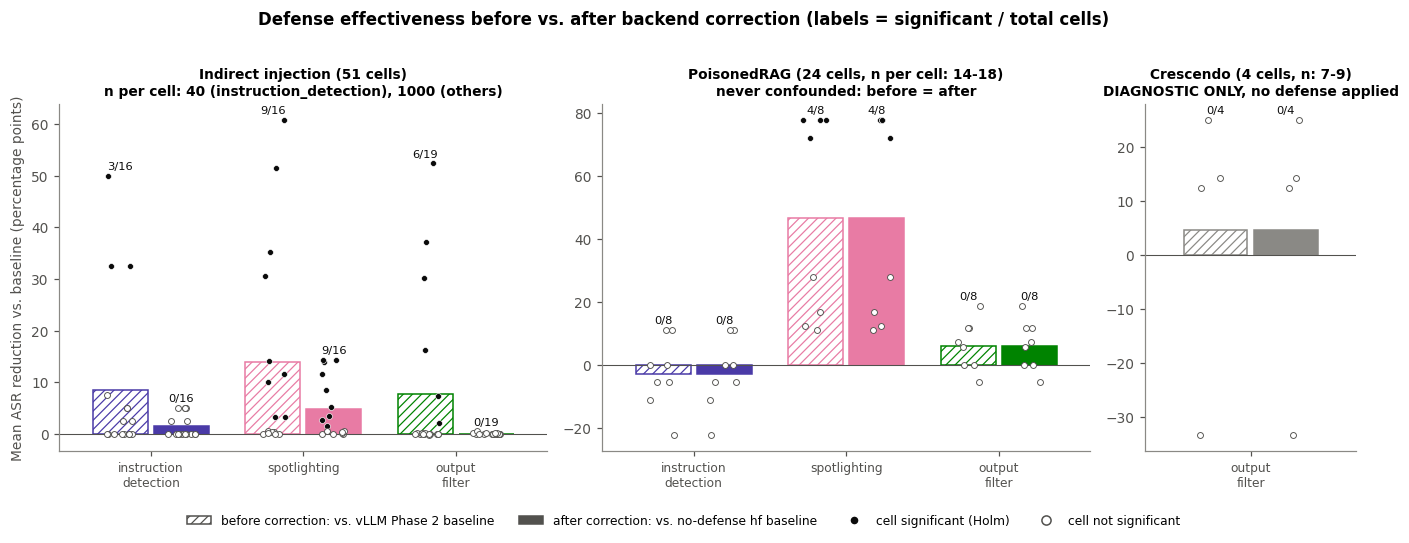

saved results\figures\fig06_phase3_backend_correction_before_after.png


cells  before_mean_pp  before_sig  after_mean_pp  after_sig
attack      defense                                                                           
crescendo   output_filter              4            4.61           0           4.61          0
injection   instruction_detection     16            8.59           3           1.56          0
            output_filter             19            7.66           6           0.05          0
            spotlighting              16           13.86           9           4.82          9
poisonedrag instruction_detection      8           -2.78           0          -2.78          0
            output_filter              8            6.18           0           6.18          0
            spotlighting               8           46.70           4          46.70          4

In [28]:
def ba_row(attack, defense, model, corpus, template, before, after):
    return dict(attack=attack, defense=defense, model=model, corpus=corpus, template=template, n=before["n"],
                before_pp=before["reduction"] * 100, before_sig=bool(before["significant_holm"]),
                after_pp=after["reduction"] * 100, after_sig=bool(after["significant_holm"]))


assert all(s["defended_measurement_valid"] is False for s in p3["crescendo_cells"].values())
ba = pd.DataFrame(
    [ba_row("injection", d, m, c, t, s, cor[d][(m, c, t)]) for (m, c, t, d), s in p3["injection_cells"].items()]
    + [ba_row("poisonedrag", d, m, c, None, s, s) for (m, c, d), s in p3["poison_cells"].items()]
    + [ba_row("crescendo", d, m, None, None, s, s) for (m, d), s in p3["crescendo_cells"].items()])
assert ba.attack.value_counts().to_dict() == {"injection": 51, "poisonedrag": 24, "crescendo": 4}
nc = ba[ba.attack != "injection"]
assert (nc.before_pp == nc.after_pp).all() and (nc.before_sig == nc.after_sig).all()


def n_range(attack, defense=None):
    g = ba[(ba.attack == attack) & ((ba.defense == defense) if defense else True)].n
    return f"{g.min()}" if g.min() == g.max() else f"{g.min()}-{g.max()}"


def ba_panel(ax, attack, defenses, title, diagnostic=False):
    rng = np.random.default_rng(0)
    for i, d in enumerate(defenses):
        g = ba[(ba.attack == attack) & (ba.defense == d)]
        col = GREY if diagnostic else DEF_COLORS[d]
        for after, x0 in ((False, i - 0.2), (True, i + 0.2)):
            f, sg = ("after_pp", "after_sig") if after else ("before_pp", "before_sig")
            ax.bar(x0, g[f].mean(), 0.36, facecolor=col if after else "white", edgecolor=col, linewidth=1,
                   hatch=None if after else "////", zorder=2)
            xs = x0 + rng.uniform(-0.09, 0.09, len(g)); s = g[sg].values
            ax.scatter(xs[s], g[f].values[s], s=15, facecolors=INK, edgecolors="white", linewidths=0.4, zorder=4)
            ax.scatter(xs[~s], g[f].values[~s], s=15, facecolors="white", edgecolors=INK2, linewidths=0.6, zorder=4)
            ax.annotate(f"{s.sum()}/{len(g)}", (x0, max(g[f].max(), g[f].mean(), 0)), xytext=(0, 4),
                        textcoords="offset points", ha="center", fontsize=7.5, color=INK)
    ax.axhline(0, color=INK2, linewidth=0.7)
    ax.set_xticks(range(len(defenses))); ax.set_xticklabels([d.replace("_", "\n") for d in defenses], fontsize=8)
    ax.set_title(title, fontsize=9); ax.set_xlim(-0.6, len(defenses) - 0.4)


fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.4), gridspec_kw={"width_ratios": [3, 3, 1.3]})
ba_panel(axes[0], "injection", DEFENSES, f"Indirect injection (51 cells)\nn per cell: {n_range('injection', 'instruction_detection')} "
         f"(instruction_detection), {n_range('injection', 'spotlighting')} (others)")
ba_panel(axes[1], "poisonedrag", DEFENSES, f"PoisonedRAG (24 cells, n per cell: {n_range('poisonedrag')})\nnever confounded: before = after")
ba_panel(axes[2], "crescendo", ["output_filter"], f"Crescendo (4 cells, n: {n_range('crescendo')})\nDIAGNOSTIC ONLY, no defense applied",
         diagnostic=True)
axes[0].set_ylabel("Mean ASR reduction vs. baseline (percentage points)")
legend_below(fig, [Patch(facecolor="white", edgecolor=INK2, hatch="////", label="before correction: vs. vLLM Phase 2 baseline"),
                   Patch(facecolor=INK2, edgecolor=INK2, label="after correction: vs. no-defense hf baseline"),
                   Line2D([], [], marker="o", linestyle="", markerfacecolor=INK, markeredgecolor="white", label="cell significant (Holm)"),
                   Line2D([], [], marker="o", linestyle="", markerfacecolor="white", markeredgecolor=INK2, label="cell not significant")],
             y=-0.07, fs=8)
save_fig(fig, "fig06_phase3_backend_correction_before_after",
         "Defense effectiveness before vs. after backend correction (labels = significant / total cells)")
display(ba.groupby(["attack", "defense"]).agg(cells=("after_pp", "size"), before_mean_pp=("before_pp", "mean"),
        before_sig=("before_sig", "sum"), after_mean_pp=("after_pp", "mean"), after_sig=("after_sig", "sum")).round(2))

**Observation.**
- Injection, `output_filter`: mean reduction falls from 7.66 to 0.05 percentage points and significant cells from 6/19 to 0/19. `instruction_detection`: 8.59 to 1.56 points, 3/16 to 0/16. Their apparent effect came from the vLLM-to-hf backend switch, not from the defense.
- Injection, `spotlighting`: 13.86 to 4.82 points, still 9/16 significant. It is the only injection defense with a real effect, and a smaller one than the uncorrected comparison suggested.
- PoisonedRAG (never confounded): only `spotlighting` has significant cells (4/8, mean 46.70 points); `output_filter` and `instruction_detection` have 0/8. These cells hold only 14-18 items, so read them as coarse.
- The Crescendo panel is diagnostic only and is not a defense result. Comparing defended runs against a baseline from a different backend would have certified defenses that do nothing (`THESIS_MASTER_RECORD.md` §8.3).

### 3.2 Backend-confound attribution

**Reads:** `backend_confound_cells` from `analyze_phase3_defense_stats.py` (vLLM baseline / hf no-defense / hf defended, three-way). **Numbers in:** `THESIS_MASTER_RECORD.md` §8.2.

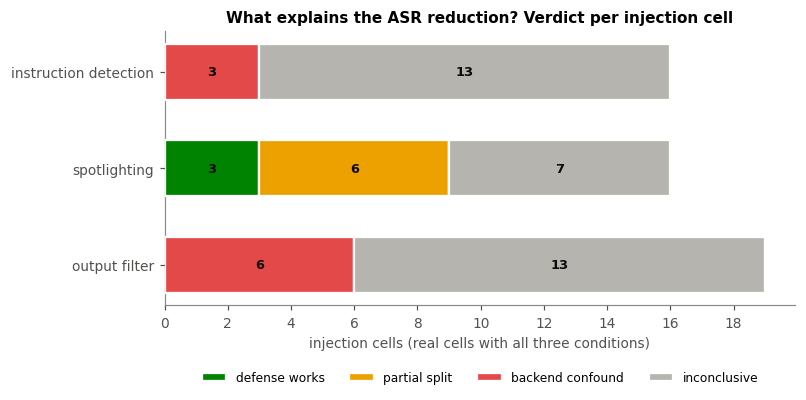

saved results\figures\fig07_phase3_backend_confound_verdicts.png


verdict,defense_works,partial_split,backend_confound,inconclusive
defense,,,,
instruction_detection,0,0,3,13
spotlighting,3,6,0,7
output_filter,0,0,6,13


In [29]:
vc = pd.DataFrame([(k[0], v["verdict"]) for k, v in p3["backend_confound_cells"].items()], columns=["defense", "verdict"])
vt = pd.crosstab(vc.defense, vc.verdict).reindex(index=DEFENSES, columns=list(VERDICT_COLORS), fill_value=0)
fig, ax = plt.subplots(figsize=(7.4, 3.8))
left = np.zeros(len(DEFENSES))
for v in VERDICT_COLORS:
    ax.barh(range(len(DEFENSES)), vt[v].values, left=left, height=0.58, color=VERDICT_COLORS[v], edgecolor="white",
            linewidth=1.5, label=v.replace("_", " "), zorder=3)
    for y, (l, w) in enumerate(zip(left, vt[v].values)):
        if w:
            ax.text(l + w / 2, y, str(w), ha="center", va="center", fontsize=8.5, color=INK, fontweight="bold")
    left += vt[v].values
ax.set_yticks(range(len(DEFENSES))); ax.set_yticklabels([d.replace("_", " ") for d in DEFENSES]); ax.invert_yaxis()
ax.set_xlabel("injection cells (real cells with all three conditions)")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_title("What explains the ASR reduction? Verdict per injection cell")
legend_below(ax, y=-0.2, fs=8)
save_fig(fig, "fig07_phase3_backend_confound_verdicts")
display(vt)

**Observation.**
- `output_filter`: 6 cells are `backend_confound` and 13 inconclusive. `instruction_detection`: 3 `backend_confound` and 13 inconclusive. Neither has a cell where the defense itself does the work.
- `spotlighting`: 3 cells `defense_works`, 6 `partial_split` (the backend explains part of the drop) and 7 inconclusive.
- The backend switch alone explains every conclusive cell for the first two defenses; only `spotlighting` has cells where the defense is responsible. Inconclusive cells are mostly near-zero-ASR cells with no room to show an effect (`THESIS_MASTER_RECORD.md` §8.2).

### 3.3 Defense-utility trade-off

**Reads:** `utility_rows` (per-cell `f1_clean` from the Phase 3 summary CSVs against the Phase 1 no-attack baseline) and the backend-corrected reductions, via `analyze_phase3_defense_stats.py`. **Numbers in:** `THESIS_MASTER_RECORD.md` §6.4.

x: ASR reduction (injection vs. no-defense hf baseline, PoisonedRAG vs. Phase 2 hf); y: defended F1 minus Phase 1 no-attack F1; diamonds: the §6.4 means; filled = Holm-significant. Crescendo has no F1 and is not plotted. PoisonedRAG cells have only 14-18 items, so their x-position is coarse.

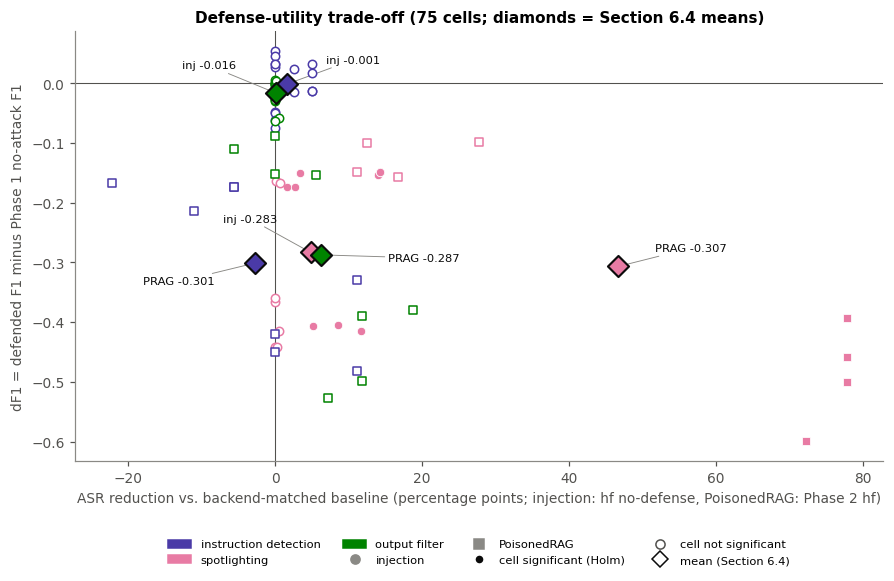

saved results\figures\fig08_phase3_defense_utility_tradeoff.png


mean reduction (pp)  mean dF1
attack      defense                                             
injection   instruction_detection               1.5625   -0.0014
            output_filter                       0.0562   -0.0161
            spotlighting                        4.8250   -0.2831
poisonedrag instruction_detection              -2.7778   -0.3011
            output_filter                       6.1778   -0.2873
            spotlighting                       46.7014   -0.3067

In [30]:
KEY = ["attack", "defense", "model", "corpus", "template"]
fill = lambda d: d.assign(template=d.template.fillna(""))
tr = (fill(util).merge(fill(ba[ba.attack != "crescendo"])[KEY + ["after_pp", "after_sig"]], on=KEY, how="left", validate="one_to_one")
      .rename(columns={"delta": "dF1", "after_pp": "reduction_pp", "after_sig": "sig"}))
assert len(tr) == 75 and tr.reduction_pp.notna().all()
means = mean_of_cell_means(tr, ["reduction_pp", "dF1"])
assert np.allclose(means.dF1, util_means.delta.reindex(means.index))

MARK = {"injection": "o", "poisonedrag": "s"}
OFF = {("injection", "instruction_detection"): (26, 14, "left"), ("injection", "output_filter"): (-26, 16, "right"),
       ("injection", "spotlighting"): (-22, 20, "right"), ("poisonedrag", "output_filter"): (44, -4, "left"),
       ("poisonedrag", "instruction_detection"): (-26, -14, "right"), ("poisonedrag", "spotlighting"): (24, 10, "left")}
fig, ax = plt.subplots(figsize=(8.2, 5.4))
for (att, d), g in tr.groupby(["attack", "defense"]):
    col = DEF_COLORS[d]
    for sig, face, edge, lw in ((True, col, "white", 0.5), (False, "white", col, 1.0)):
        s = g[g.sig == sig]
        ax.scatter(s.reduction_pp, s.dF1, marker=MARK[att], s=30, facecolors=face, edgecolors=edge, linewidths=lw, zorder=4)
    mx, my = means.loc[(att, d)]
    ax.scatter(mx, my, marker="D", s=95, facecolors=col, edgecolors=INK, linewidths=1.4, zorder=6)
    dx, dy, ha = OFF[(att, d)]
    ax.annotate(f"{'inj' if att == 'injection' else 'PRAG'} {my:+.3f}", (mx, my), xytext=(dx, dy), textcoords="offset points",
                fontsize=7.5, color=INK, ha=ha, arrowprops=dict(arrowstyle="-", color=GREY, linewidth=0.6, shrinkA=0, shrinkB=5))
ax.axhline(0, color=INK2, linewidth=0.7); ax.axvline(0, color=INK2, linewidth=0.7)
ax.set_xlabel("ASR reduction vs. backend-matched baseline (percentage points; injection: hf no-defense, PoisonedRAG: Phase 2 hf)")
ax.set_ylabel("dF1 = defended F1 minus Phase 1 no-attack F1")
ax.set_title("Defense-utility trade-off (75 cells; diamonds = Section 6.4 means)")
legend_below(ax, [Patch(color=DEF_COLORS[d], label=d.replace("_", " ")) for d in DEFENSES] + [
    Line2D([], [], marker="o", linestyle="", color=GREY, label="injection"),
    Line2D([], [], marker="s", linestyle="", color=GREY, label="PoisonedRAG"),
    Line2D([], [], marker="o", linestyle="", markerfacecolor=INK, markeredgecolor="white", label="cell significant (Holm)"),
    Line2D([], [], marker="o", linestyle="", markerfacecolor="white", markeredgecolor=INK2, label="cell not significant"),
    Line2D([], [], marker="D", linestyle="", markerfacecolor="white", markeredgecolor=INK, markersize=7, label="mean (Section 6.4)")],
    y=-0.16, fs=7.5)
save_fig(fig, "fig08_phase3_defense_utility_tradeoff")
display(means.round(4).rename(columns={"reduction_pp": "mean reduction (pp)", "dF1": "mean dF1"}))

**Observation.**
- Injection: `instruction_detection` (dF1 -0.001) and `output_filter` (-0.016) barely cost utility but show no confirmed reduction; `spotlighting` has a confirmed reduction but costs -0.283 F1.
- PoisonedRAG: all three defenses cost about 0.3 F1 (-0.301, -0.287, -0.307) because none repairs the poisoned retrieval; only `spotlighting` reduces ASR (mean 46.7 points, 4/8 cells significant).
- No tested defense combines a confirmed robustness effect with preserved utility. `instruction_detection`'s null result rests on n = 40 per cell, and all 10 of its genuinely blocked items had a flagged passage (`THESIS_MASTER_RECORD.md` §6.1), so it may be underpowered rather than ineffective.

### 3.4 `instruction_detection` false-positive check

**Reads:** `instruction_detection_fp_check_results.json`. **Numbers in:** not tabulated in the master record, so these rates are not cross-checked; only `flagged / n == flag_rate` is asserted.

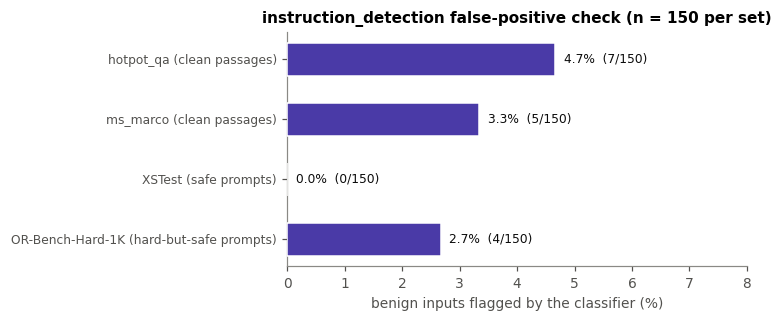

saved results\figures\fig09_instruction_detection_fp_check.png


,label,n,flagged,flag_rate
0,hotpot_qa (clean passages),150,7,0.046667
1,ms_marco (clean passages),150,5,0.033333
2,XSTest (safe prompts),150,0,0.000000
3,OR-Bench-Hard-1K (hard-but-safe prompts),150,4,0.026667


In [31]:
fp = pd.DataFrame(json.loads(FP_JSON.read_text(encoding="utf-8")))
assert (fp.n == 150).all() and np.allclose(fp.flagged / fp.n, fp.flag_rate), "fp-check JSON is internally inconsistent"
fig, ax = plt.subplots(figsize=(7, 3.0))
ax.barh(range(len(fp)), fp.flag_rate * 100, height=0.55, color=DEF_COLORS["instruction_detection"], edgecolor="white", zorder=3)
for i, r in fp.iterrows():
    ax.text(r.flag_rate * 100 + 0.15, i, f"{r.flag_rate * 100:.1f}%  ({r.flagged}/{r.n})", va="center", fontsize=8, color=INK)
ax.set_yticks(range(len(fp))); ax.set_yticklabels(fp.label, fontsize=8); ax.invert_yaxis()
ax.set_xlim(0, 8); ax.set_xlabel("benign inputs flagged by the classifier (%)")
ax.set_title("instruction_detection false-positive check (n = 150 per set)")
save_fig(fig, "fig09_instruction_detection_fp_check")
display(fp)

**Observation.**
- The classifier flags 4.7% (7/150) of clean `hotpot_qa` passages, 3.3% (5/150) of `ms_marco` passages, 0% of XSTest safe prompts and 2.7% (4/150) of OR-Bench-Hard prompts.
- A few percent of legitimate content is dropped, which is consistent with its near-zero utility cost on injection (dF1 -0.001). These rates are not tabulated in the master record.

## 4. Figure manifest

In [32]:
for p in sorted(FIG_DIR.glob("fig*.png")):
    with Image.open(p) as im:
        print(f"{p.relative_to(ROOT)}  {im.size[0]}x{im.size[1]}px  dpi={tuple(round(x) for x in im.info['dpi'])}")

results\figures\fig01_phase1_baseline_f1_em.png  2676x1207px  dpi=(300, 300)
results\figures\fig02_nq_open_exclusion_evidence.png  2256x1212px  dpi=(300, 300)
results\figures\fig03_injection_asr_model_template.png  3726x1421px  dpi=(300, 300)
results\figures\fig04_poisonedrag_asr_model_corpus.png  1931x1223px  dpi=(300, 300)
results\figures\fig05_crescendo_asr_bootstrap_ci.png  2196x1477px  dpi=(300, 300)
results\figures\fig06_phase3_backend_correction_before_after.png  3842x1482px  dpi=(300, 300)
results\figures\fig07_phase3_backend_confound_verdicts.png  2197x1090px  dpi=(300, 300)
results\figures\fig08_phase3_defense_utility_tradeoff.png  2436x1590px  dpi=(300, 300)
results\figures\fig09_instruction_detection_fp_check.png  2133x874px  dpi=(300, 300)


## 5. Conclusions

Drawn from the observations above, for the 4 models, 2 corpora, 3 attacks and 3 defenses evaluated here; full discussion in `docs/THESIS_MASTER_RECORD.md`.

1. **The three attacks are driven by different factors.** Injection depends on the model and the template (`ministral-3-8b` and the process-hijack templates), PoisonedRAG on the corpus, and Crescendo shows no significant model ranking in outcome, only in mechanism. No single robustness score summarizes all three.
2. **Backend correction changes the defense picture.** The apparent injection gains of `output_filter` (6/19 significant) and `instruction_detection` (3/16) disappear once the vLLM-to-hf switch is controlled (0/19, 0/16). `spotlighting` keeps 9/16 significant cells at a smaller effect (13.9 to 4.8 points).
3. **No tested defense is both effective and cheap.** `spotlighting` is the only one with a confirmed effect and costs -0.28 F1 on injection; on PoisonedRAG every defense costs about -0.3 F1 because none repairs the retrieval. `instruction_detection` is nearly free on utility but unconfirmed at n = 40.
4. **Comparisons must hold the inference backend constant.** Otherwise a backend artifact can be mistaken for a defense effect.
5. **Limits of these results.** `nq_open` is excluded as a corpus-design limitation. Phase 3 PoisonedRAG cells have 14-18 items and Crescendo cells 7-9, and Crescendo/`output_filter` is diagnostic only. The false-positive rates are not cross-checked against the master record.